In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
!pip install -r /content/drive/MyDrive/ChinesePun/requirements.txt

In [22]:
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import evaluate
import pandas as pd
import os

In [23]:
# 1. Load training data from CSV
data_path = "/content/drive/MyDrive/ChinesePun/data/combined_pun_nonpun.csv"
df = pd.read_csv(data_path)

print("Data shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Column dtypes:")
print(df.dtypes)
print("\nFirst few rows:")
print(df.head(10))
print("\nData info:")
print(df.info())


Data shape: (740, 7)
Columns: ['id', 'text', 'Surface Meaning', 'Hidden Text', 'Hidden Meaning', 'Language', 'label']
Column dtypes:
id                  int64
text               object
Surface Meaning    object
Hidden Text        object
Hidden Meaning     object
Language           object
label               int64
dtype: object

First few rows:
   id         text                      Surface Meaning       Hidden Text  \
0   0        莞安大小姐              甄嬛（莞莞）和安陵容被華妃叫去翊坤宮表演彈唱。             晚安大小姐   
1   1         黑暗容藥                      安陵容為了討好甄嬛，以人血入藥              黑暗榮耀   
2   2         慣蘭高手     皇帝原諒華妃（年世蘭）陷害甄嬛和其他嬪妃太多次，慣壞年世蘭的高手              灌籃高手   
3   3          沈預算  沈眉莊初得寵學習協理後宮，提議節省開銷，把綠豆和冰糖的錢分給各宮的奴才               審預算   
4   4         無性升職               甄嬛在花園盪鞦韆，還沒給皇上侍寢就直接升貴人              無性生殖   
5   5  朧 time no 熹                         熹妃許久回宮終於見到朧月  Long time no see   
6   6      Duck 不必                                   鴨子              大可不必   
7   7      貪生 pass                    

In [24]:
# 2. Handle labels
df["label"] = df["label"].astype(int)

# Check class distribution
class_counts = df["label"].value_counts()
print("\nClass distribution:")
print(class_counts)
print("Class percentages:")
print(class_counts / len(df))




Class distribution:
label
1    404
0    336
Name: count, dtype: int64
Class percentages:
label
1    0.545946
0    0.454054
Name: count, dtype: float64


In [25]:
# 3. Train/Val split
# Ensure label column is properly formatted
df = df.dropna(subset=['text', 'label'])  # Remove any rows with NaN
df['text'] = df['text'].astype(str)
df['label'] = df['label'].astype(int)

# Perform train/val split with stratification
X_train, X_val, y_train, y_val = train_test_split(
    df["text"], df["label"], test_size=0.2, random_state=42, stratify=df["label"]
)

# Create dataframes
train_df = pd.DataFrame({"text": X_train.values, "label": y_train.values})
val_df = pd.DataFrame({"text": X_val.values, "label": y_val.values})

# Create HuggingFace dataset
dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df, preserve_index=False),
    "validation": Dataset.from_pandas(val_df, preserve_index=False)
})

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 592
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 148
    })
})


In [26]:
import torch
print(torch.__version__)
print(torch.version.cuda)

2.9.0+cu126
12.6


In [33]:
# ============================================================
# DEVICE CONFIGURATION - Set USE_GPU to True if GPU available
# ============================================================
import torch

USE_GPU = True  # Set to True if you have GPU (CUDA/MPS)

# Detect available device
if USE_GPU:
    if torch.cuda.is_available():
        device = "cuda"
        print("✅ GPU (CUDA) detected and enabled")
    elif torch.backends.mps.is_available():
        device = "mps"  # Mac with Apple Silicon
        print("✅ GPU (MPS) detected and enabled")
    else:
        device = "cpu"
        print("⚠️ GPU requested but not available, falling back to CPU")
else:
    device = "cpu"
    print("✅ Using CPU (set USE_GPU=True to enable GPU)")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device.upper()}")

✅ GPU (CUDA) detected and enabled
PyTorch version: 2.9.0+cu126
Device: CUDA


In [34]:
from transformers import EarlyStoppingCallback
import torch

# 4. Tokenizer - Using Chinese BERT model
model_name = "bert-base-chinese"
tokenizer = AutoTokenizer.from_pretrained(model_name)

print(f"Dataset before tokenization:")
print(dataset)

def tokenize(batch):
    try:
        result = tokenizer(batch["text"], truncation=True, padding="max_length", max_length=256)
        return result
    except Exception as e:
        print(f"Error in tokenize function: {e}")
        raise

try:
    # Tokenize dataset
    print("\nStarting tokenization...")
    dataset = dataset = dataset.map(tokenize, batched=True)

    print("✅ Tokenization successful")

    # Set format
    #dataset = dataset.set_format("torch", columns=["input_ids", "token_type_ids", "attention_mask", "label"])

    print(f"\nDataset after tokenization:")
    print(dataset)
    print("✅ Dataset preprocessing complete!")

except Exception as e:
    print(f"❌ ERROR during tokenization: {type(e).__name__}: {e}")
    import traceback
    traceback.print_exc()
    dataset = None


Dataset before tokenization:
DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 592
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 148
    })
})

Starting tokenization...


Map:   0%|          | 0/592 [00:00<?, ? examples/s]

Map:   0%|          | 0/148 [00:00<?, ? examples/s]

✅ Tokenization successful

Dataset after tokenization:
DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 592
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 148
    })
})
✅ Dataset preprocessing complete!


In [35]:
# 5. Load Model and Create Trainer
# Load the model
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# Move model to device
model = model.to(device)
print(f"✅ Model loaded and moved to {device}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-chinese
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded and moved to cuda


In [36]:
# 6. Metrics
accuracy = evaluate.load("accuracy")
f1_macro = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy.compute(predictions=preds, references=labels)["accuracy"],
        "f1_macro": f1_macro.compute(predictions=preds, references=labels, average="macro")["f1"]
    }

In [37]:
output_dir = "./models/pun_classifier"
os.makedirs(output_dir, exist_ok=True)

# Adjust batch sizes based on device
if device == "cpu":
    batch_size_train = 2
    batch_size_eval = 2
    num_epochs = 2
else:  # GPU
    batch_size_train = 16
    batch_size_eval = 32
    num_epochs = 5

args = TrainingArguments(
    output_dir=output_dir,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=batch_size_train,
    per_device_eval_batch_size=batch_size_eval,
    num_train_epochs=num_epochs,
    weight_decay=0.01,
    warmup_ratio=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    seed=42,
    logging_steps=1
)

print(f"\n{'='*60}")
print(f"Training Configuration:")
print(f"{'='*60}")
print(f"Device: {device.upper()}")
print(f"Batch Size (Train/Eval): {batch_size_train}/{batch_size_eval}")
print(f"Epochs: {num_epochs}")
print(f"Output Directory: {output_dir}")
print(f"{'='*60}\n")

# 8. Create Trainer
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"],
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print("✅ Trainer created successfully!")


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.



Training Configuration:
Device: CUDA
Batch Size (Train/Eval): 16/32
Epochs: 5
Output Directory: ./models/pun_classifier

✅ Trainer created successfully!


In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

trainer.train()
metrics = trainer.evaluate()
print(metrics)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.094620,0.122838,0.972973,0.972794
2,0.009028,0.110202,0.966216,0.966029
3,0.002330,0.138672,0.972973,0.972729


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

{'eval_loss': 0.12254231423139572, 'eval_accuracy': 0.9662162162162162, 'eval_f1_macro': 0.9659535311709224, 'eval_runtime': 2.0272, 'eval_samples_per_second': 73.008, 'eval_steps_per_second': 2.466, 'epoch': 3.0}



Classification Report:
              precision    recall  f1-score   support

     Non-Pun       0.96      0.97      0.96        67
         Pun       0.97      0.96      0.97        81

    accuracy                           0.97       148
   macro avg       0.97      0.97      0.97       148
weighted avg       0.97      0.97      0.97       148



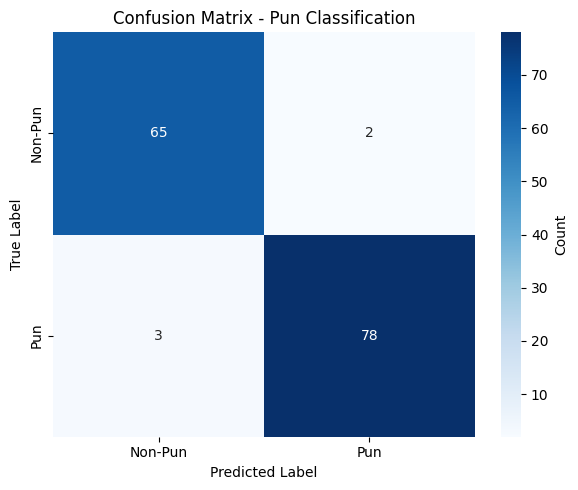


✅ Model training completed!
Model saved to: ./models/pun_classifier


In [39]:
# 11. Confusion Matrix & Classification Report
predictions = trainer.predict(dataset["validation"])
y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=-1)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, labels=[0, 1], target_names=["Non-Pun", "Pun"]))

# Plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-Pun", "Pun"],
            yticklabels=["Non-Pun", "Pun"],
            cbar_kws={'label': 'Count'})
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Pun Classification")
plt.tight_layout()
plt.show()

print("\n✅ Model training completed!")
print(f"Model saved to: {output_dir}")

## Inference - Identify Puns in New Text

In [40]:
# Test with example texts
test_texts = [
    "这个笑话很有趣。",
    "我想去北京旅游,因为我想看看真正的\"首都\"。",
    "今天天气很好。",
    "这本书讲的是\"书虫\"的故事。"
]

In [41]:
def predict_pun(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding="max_length", max_length=256)
    inputs = {k: v.to(trainer.model.device) for k, v in inputs.items()}

    import torch
    with torch.no_grad():
        outputs = trainer.model(**inputs) # Direct model call

    logits = outputs.logits
    y_pred = np.argmax(logits.cpu().numpy(), axis=-1)

    return y_pred

In [42]:
for text in test_texts:
    y_pred = predict_pun(text)
    print(f"Text: {text} Prediction: {'Pun' if y_pred[0] == 1 else 'Non-Pun'}")

Text: 这个笑话很有趣。 Prediction: Non-Pun
Text: 我想去北京旅游,因为我想看看真正的"首都"。 Prediction: Non-Pun
Text: 今天天气很好。 Prediction: Non-Pun
Text: 这本书讲的是"书虫"的故事。 Prediction: Non-Pun
